# Aprendizaje No Supervisado sobre Objetos Celestes
## Sloan Digital Sky Survey — SDSS DR17

**Autor:** Jheison Martinez Bolivar
**Maestría:** Inteligencia Artificial
**Fecha:** Septiembre 2026
**Dataset:** [Stellar Classification Dataset SDSS17 – Kaggle](https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17)

---

### Planteamiento del Proyecto
Este cuaderno trabaja el catalogo `star_classification.csv` del Sloan Digital Sky Survey, un telescopio que lleva dos decadas fotografiando el cielo de forma sistematica. Cada fila es un objeto luminoso detectado y las columnas son las mediciones que se le tomaron.

Los objetos son de tres tipos: **estrellas**, **galaxias** y **cuasares**. En una imagen los tres se ven como manchas de luz, y distinguirlos es un problema real de la astronomia.

La actividad pide aplicar reduccion de dimensionalidad y agrupamiento sobre datos sin etiquetar, comparando dos modelos no supervisados: PCA, K-medias, mezcla gaussiana e informacion mutua.

Las preguntas de investigacion se fijan despues del EDA.


In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 110

dataset_dir = Path(kagglehub.dataset_download('fedesoriano/stellar-classification-dataset-sdss17'))
csv_path = dataset_dir / 'star_classification.csv'
df = pd.read_csv(csv_path)

print(f'Ruta del archivo: {csv_path}')
print(f'Filas y columnas: {df.shape}')
print()
print('Tipos de datos:')
print(df.dtypes.to_string())
print()
print('Valores nulos por columna:')
print(df.isna().sum().to_string())
print()
print('Primeros registros:')
display(df.head())


/home/jheisonmblivecom/Academic/Deriverables/ML/clustering-estelar-sdss/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ruta del archivo: /home/jheisonmblivecom/.cache/kagglehub/datasets/fedesoriano/stellar-classification-dataset-sdss17/versions/1/star_classification.csv
Filas y columnas: (100000, 18)

Tipos de datos:
obj_ID         float64
alpha          float64
delta          float64
u              float64
g              float64
r              float64
i              float64
z              float64
run_ID           int64
rerun_ID         int64
cam_col          int64
field_ID         int64
spec_obj_ID    float64
class              str
redshift       float64
plate            int64
MJD              int64
fiber_ID         int64

Valores nulos por columna:
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0

Primeros registros:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


## Que significa cada columna

Las 18 columnas vienen de **dos instrumentos distintos**:

**Fotometria** — la camara, que mide brillo a traves de filtros pasa banda sobre el espectro electromagnetico.

| columna | que es |
|---|---|
| `u`, `g`, `r`, `i`, `z` | brillo medido con cinco filtros, del ultravioleta al infrarrojo |
| `alpha`, `delta` | coordenadas en el cielo, equivalentes a longitud y latitud |

**Espectroscopia** — descompone la luz en su espectro completo. Mucho mas costosa de obtener.

| columna | que es |
|---|---|
| `redshift` | corrimiento al rojo: cuanto se estira la luz por la expansion del universo, una medida directa de distancia |
| `class` | el tipo de objeto |
| `plate`, `MJD`, `fiber_ID`, `spec_obj_ID` | placa, fecha y fibra optica con que se tomo el espectro |

**Identificadores del instrumento** — numeros de serie, no miden nada.

| columna | que es |
|---|---|
| `obj_ID`, `run_ID`, `rerun_ID`, `cam_col`, `field_ID` | objeto, pasada del telescopio, columna de la camara y region fotografiada |

Un detalle de las cinco bandas que cambia como se leen: estan en **magnitudes astronomicas**, escala logaritmica e **invertida**. Un numero mas alto significa objeto mas **debil**.


In [2]:
etiqueta = df['class'].copy()

print('Distribucion de la etiqueta (se aparta, no se usa para entrenar):')
conteo = etiqueta.value_counts()
display(pd.DataFrame({'objetos': conteo, 'porcentaje': (100 * conteo / len(df)).round(1)}))

bandas = ['u', 'g', 'r', 'i', 'z']
print('Resumen de las cinco bandas fotometricas:')
display(df[bandas].describe().round(2))


Distribucion de la etiqueta (se aparta, no se usa para entrenar):


,objetos,porcentaje
class,,
GALAXY,59445,59.4
STAR,21594,21.6
QSO,18961,19.0


Resumen de las cinco bandas fotometricas:


,u,g,r,i,z
count,100000.00,100000.00,100000.00,100000.00,100000.00
mean,21.98,20.53,19.65,19.08,18.67
std,31.77,31.75,1.85,1.76,31.73
min,-9999.00,-9999.00,9.82,9.47,-9999.00
25%,20.35,18.97,18.14,17.73,17.46
50%,22.18,21.10,20.13,19.41,19.00
75%,23.69,22.12,21.04,20.40,19.92
max,32.78,31.60,29.57,32.14,29.38


## Auditoria de las 18 columnas

Antes de reducir dimensiones hay que saber cuantas dimensiones **reales** hay. Una columna constante o un identificador unico ocupan lugar en la matriz sin aportar nada, y PCA no los distingue de una medicion legitima: los rota igual que a las demas.

Dos criterios permiten descartar sin discusion, porque son propiedades de la columna y no interpretaciones mias:

- **Constante**: un solo valor distinto en las 100 000 filas. Varianza cero, no puede separar nada.
- **Identificador unico**: tantos valores distintos como filas. Es una matricula, no una medida.

Los metadatos del instrumento —la placa, la fecha, la columna de la camara— son otra historia. La tentacion es descartarlos diciendo que "describen como se tomo el dato y no el objeto", pero eso es una suposicion, no evidencia. Podria haber lecturas del mismo objeto con configuraciones distintas, o efectos del instrumento que si dejen rastro. Antes de eliminarlos hay que medir si llevan informacion.


In [3]:
origen = {
    'obj_ID': 'identificador', 'alpha': 'fotometria', 'delta': 'fotometria',
    'u': 'fotometria', 'g': 'fotometria', 'r': 'fotometria', 'i': 'fotometria', 'z': 'fotometria',
    'run_ID': 'identificador', 'rerun_ID': 'identificador', 'cam_col': 'identificador',
    'field_ID': 'identificador', 'spec_obj_ID': 'espectroscopia', 'class': 'espectroscopia',
    'redshift': 'espectroscopia', 'plate': 'espectroscopia', 'MJD': 'espectroscopia',
    'fiber_ID': 'espectroscopia',
}

n = len(df)
auditoria = pd.DataFrame({
    'origen': pd.Series(origen),
    'valores_distintos': df.nunique(),
    'proporcion_unicos': (df.nunique() / n).round(3),
})
auditoria['constante'] = auditoria['valores_distintos'] == 1
auditoria['identificador_unico'] = auditoria['valores_distintos'] == n

display(auditoria)

print('Columnas constantes:', auditoria.index[auditoria['constante']].tolist())
print('Columnas con un valor distinto por fila:', auditoria.index[auditoria['identificador_unico']].tolist())


,origen,valores_distintos,proporcion_unicos,constante,identificador_unico
obj_ID,identificador,78053,0.781,False,False
alpha,fotometria,99999,1.000,False,False
delta,fotometria,99999,1.000,False,False
u,fotometria,93748,0.937,False,False
g,fotometria,92651,0.927,False,False
r,fotometria,91901,0.919,False,False
i,fotometria,92019,0.920,False,False
z,fotometria,92007,0.920,False,False
run_ID,identificador,430,0.004,False,False
rerun_ID,identificador,1,0.000,True,False


Columnas constantes: ['rerun_ID']
Columnas con un valor distinto por fila: ['spec_obj_ID']


## Como estan las dimensiones que si son mediciones

Descartados los identificadores, quedan las columnas que miden algo. Antes de aplicar PCA hay que ver **cuanta redundancia hay entre ellas**, porque de eso depende que PCA tenga algo que comprimir: si las variables fueran independientes, no habria nada que ganar rotando el espacio.

Se incluyen tambien los metadatos del instrumento, porque son los que quedaron en duda y no se pueden juzgar sin mirarlos.

Antes hay que limpiar un detalle: el SDSS marca las mediciones fallidas con el codigo `-9999`. Una magnitud negativa no es un valor pequeno, es un dato que no existe, y con esa fila dentro las correlaciones salen distorsionadas.


Filas con codigo de medicion fallida (-9999): 1


,u,g,r,i,z,redshift,class
79543,-9999.0,-9999.0,18.1656,18.01675,-9999.0,0.000089,STAR


Filas conservadas: 99999 de 100000


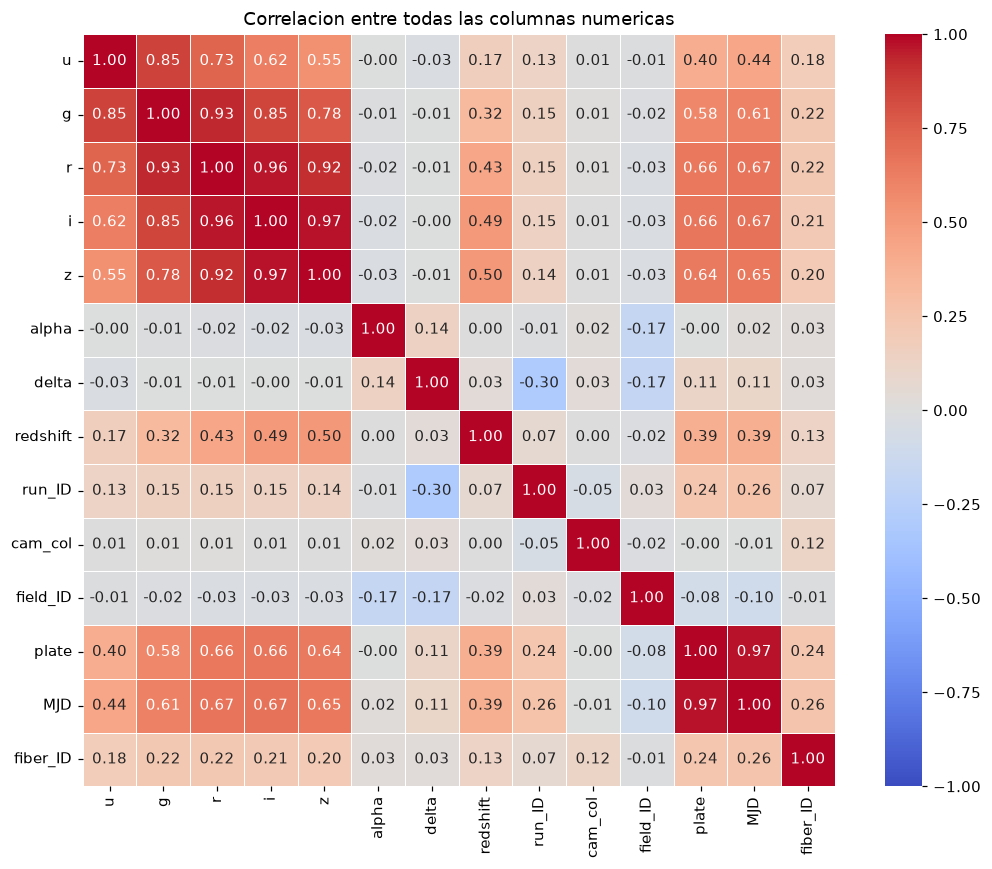

In [4]:
bandas = ['u', 'g', 'r', 'i', 'z']
numericas = bandas + ['alpha', 'delta', 'redshift', 'run_ID', 'cam_col', 'field_ID', 'plate', 'MJD', 'fiber_ID']

falla = (df[bandas] < 0).any(axis=1)
print(f'Filas con codigo de medicion fallida (-9999): {int(falla.sum())}')
display(df.loc[falla, bandas + ['redshift', 'class']])

limpio = df.loc[~falla].reset_index(drop=True)
etiqueta_limpia = etiqueta.loc[~falla].reset_index(drop=True)
print(f'Filas conservadas: {len(limpio)} de {len(df)}')

plt.figure(figsize=(10, 8))
sns.heatmap(limpio[numericas].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlacion entre todas las columnas numericas')
plt.tight_layout()
plt.show()


### Lo que muestra el mapa de calor

**Las bandas forman una escalera.** Las vecinas en longitud de onda estan casi pegadas, y la correlacion cae a medida que los filtros se alejan entre si: `i` y `z` son casi la misma medicion, mientras que `u` y `z`, los dos extremos, comparten bastante menos. Tiene sentido fisico, porque el espectro de un objeto es una curva continua y filtros contiguos muestrean puntos casi iguales de esa curva. Es exactamente la condicion en la que PCA tiene algo que comprimir.

**`u` es la banda mas suelta del grupo.** Es la unica en el ultravioleta y la que menos comparte con las demas. Si alguna banda va a aportar algo distinto, deberia ser esa.

**`alpha` y `delta` no se relacionan con nada.** Donde esta un objeto en el cielo no tiene que ver con su brillo ni con ninguna otra medicion. Era esperable, pero conviene tenerlo confirmado antes de descartarlas.

**`plate` y `MJD` son practicamente la misma columna**, y ademas correlacionan con las bandas de forma nada despreciable, mas fuerte con las rojas que con `u`. Que la placa de aluminio y la fecha de observacion se muevan junto con el brillo de los objetos no tiene ninguna explicacion fisica, y es lo que obliga a mirarlas con cuidado antes de decidir si entran o no.

### Lo que el mapa no puede responder

La correlacion mide si dos columnas se mueven juntas, y solo de forma lineal. No dice cuanto sabe cada columna sobre **el tipo de objeto**, que es la pregunta que importa aqui, y menos aun si esa relacion no es lineal.

Para eso hace falta otra medida. La **informacion mutua** responde justamente eso: cuanta incertidumbre sobre el tipo se reduce al conocer el valor de una columna. Cero significa que la columna no dice nada; el techo es la entropia de la etiqueta, que la celda siguiente calcula. Se reporta en **nats**, porque usa logaritmo natural.

Junto a la medida se calcula una **linea base al azar**: se permuta la etiqueta y se vuelve a medir. Sirve para saber cuanto de cada resultado es relacion real y cuanto es ruido del estimador, y en la tabla siguiente esa diferencia resulta importar en varias columnas.


Entropia de la etiqueta, maximo alcanzable: 0.9554 nats


,valores_distintos,mi_medida,mi_al_azar,exceso_sobre_azar,origen
redshift,99294,0.8018,0.0005,0.8014,espectroscopia
plate,6284,0.3383,0.0692,0.2691,espectroscopia
MJD,2180,0.2151,0.0231,0.1920,espectroscopia
z,92006,0.1454,0.0005,0.1449,fotometria
run_ID,430,0.1477,0.0044,0.1432,identificador
g,92650,0.1204,0.0000,0.1204,fotometria
i,92018,0.1096,0.0000,0.1096,fotometria
u,93747,0.1004,0.0001,0.1003,fotometria
r,91900,0.0757,0.0008,0.0749,fotometria
fiber_ID,1000,0.0584,0.0103,0.0481,espectroscopia


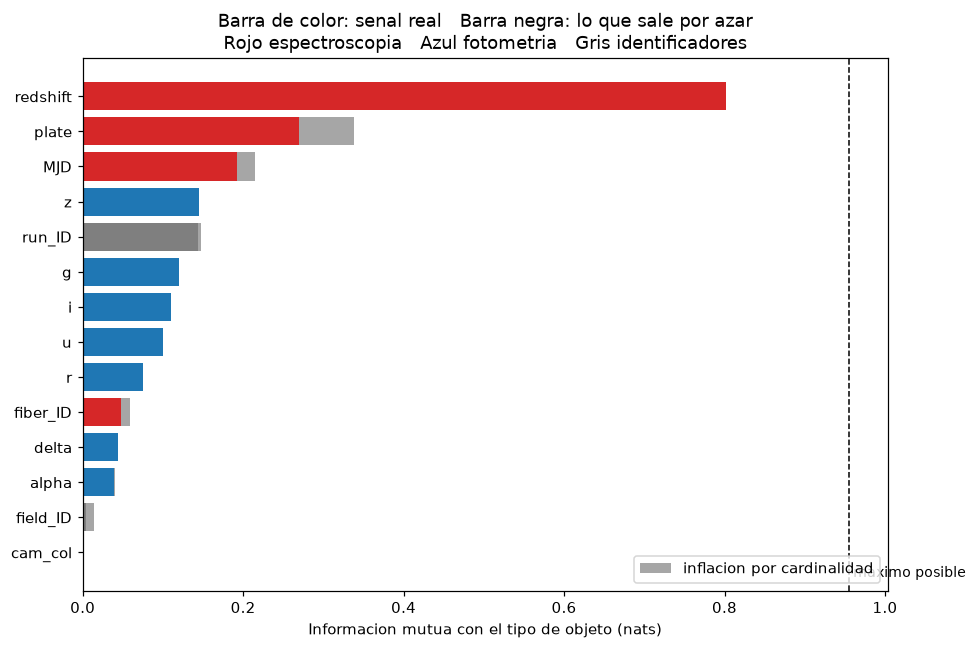

In [5]:
from sklearn.feature_selection import mutual_info_classif

candidatas = ['u', 'g', 'r', 'i', 'z', 'alpha', 'delta', 'redshift',
              'run_ID', 'cam_col', 'field_ID', 'plate', 'MJD', 'fiber_ID']
discretas = [c in ('run_ID', 'cam_col', 'field_ID', 'plate', 'MJD', 'fiber_ID') for c in candidatas]

proporciones = etiqueta_limpia.value_counts(normalize=True)
entropia = float(-(proporciones * np.log(proporciones)).sum())
print(f'Entropia de la etiqueta, maximo alcanzable: {entropia:.4f} nats')

mi = mutual_info_classif(limpio[candidatas], etiqueta_limpia,
                         discrete_features=discretas, random_state=0)

generador = np.random.default_rng(0)
nulos = [mutual_info_classif(limpio[candidatas],
                             pd.Series(generador.permutation(etiqueta_limpia.to_numpy())),
                             discrete_features=discretas, random_state=0)
         for _ in range(3)]
mi_azar = np.mean(nulos, axis=0)

grupo = {c: ('fotometria' if c in ('u', 'g', 'r', 'i', 'z', 'alpha', 'delta')
             else 'espectroscopia' if c in ('redshift', 'plate', 'MJD', 'fiber_ID')
             else 'identificador') for c in candidatas}

tabla = pd.DataFrame({
    'valores_distintos': limpio[candidatas].nunique().values,
    'mi_medida': mi.round(4),
    'mi_al_azar': mi_azar.round(4),
    'exceso_sobre_azar': (mi - mi_azar).round(4),
    'origen': [grupo[c] for c in candidatas],
}, index=candidatas).sort_values('exceso_sobre_azar', ascending=False)
display(tabla)

colores = {'fotometria': 'tab:blue', 'espectroscopia': 'tab:red', 'identificador': 'tab:gray'}
fig, ax = plt.subplots(figsize=(9, 6))
orden = tabla.index[::-1]
ax.barh(orden, tabla.loc[orden, 'exceso_sobre_azar'],
        color=[colores[g] for g in tabla.loc[orden, 'origen']])
ax.barh(orden, tabla.loc[orden, 'mi_al_azar'],
        left=tabla.loc[orden, 'exceso_sobre_azar'],
        color='black', alpha=0.35, label='inflacion por cardinalidad')
ax.axvline(entropia, color='black', linestyle='--', linewidth=1)
ax.text(entropia, -0.7, ' maximo posible', fontsize=9)
ax.set_xlabel('Informacion mutua con el tipo de objeto (nats)')
ax.set_title('Barra de color: senal real   Barra negra: lo que sale por azar\n'
             'Rojo espectroscopia   Azul fotometria   Gris identificadores')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Observaciones del EDA

- **Estructura**: 100 000 objetos x 18 columnas, sin nulos. La etiqueta esta desbalanceada, con las galaxias cerca del 60%.
- **Una sola fila corrupta**, con el codigo `-9999` que el SDSS usa para marcar mediciones fallidas. Se descarta.
- **`rerun_ID` es constante** y **`spec_obj_ID` tiene un valor por fila**. Ninguna puede separar nada.
- **Las bandas rojas son muy redundantes entre si** y `u` es la mas suelta del grupo. Ahi es donde PCA tiene material.
- **`alpha` y `delta` casi no correlacionan con nada.**
- **`plate` y `MJD` son practicamente la misma variable** y correlacionan con las bandas sin que haya razon fisica para ello.

### Lo que matiza la informacion mutua

Al medir contra la linea base al azar aparecen dos correcciones:

**El estimador se infla con la cardinalidad.** `plate` tiene miles de valores distintos y por eso solo ya arranca con informacion mutua apreciable incluso con la etiqueta permutada. Su senal real es lo que queda por encima. `field_ID` es el caso extremo: casi todo artefacto.

**`alpha` y `delta` no son cero.** Su exceso sobre el azar es pequeno pero real, por encima de `field_ID` y `cam_col`. Informan poco, no nada.

### El problema no es cuanto informan, es de donde sale

`plate`, `MJD` y `run_ID` superan a las bandas incluso descontado el azar, y `run_ID` queda a la altura de la mejor de las cinco. Si el criterio fuera quedarse con lo que mas informa, habria que conservarlos.

Pero ninguno mide nada del objeto: son la placa donde se montaron las fibras opticas, la noche de la observacion y la pasada del telescopio. Que predigan el tipo no es fisica, es **diseno del muestreo**: el SDSS dedico campanas enteras a buscar cuasares y otras a relevar galaxias. La informacion no esta en el cielo, esta en el calendario del telescopio. Un modelo que las use puede acertar mucho sin haber aprendido nada, y ese acierto no se traslada a ningun otro catalogo.

Con `redshift` el problema es distinto y peor. Es una medicion fisica legitima y la mas informativa del dataset, pero **no es separable de la etiqueta**. Para conocer el redshift hay que identificar lineas espectrales desplazadas, y una linea aislada no se puede identificar: hay que reconocer el patron completo, que es distinto para una estrella, una galaxia y un cuasar. El ajuste prueba plantillas de tipo a distintos redshifts hasta que encaje, y devuelve el par. **No se puede medir el corrimiento sin suponer que tipo de objeto es, ni determinar el tipo sin conocer el corrimiento.** Usarlo como entrada y validar contra `class` seria comprobar que dos salidas del mismo ajuste coinciden.

Conviene aclarar que el dataset no trae diccionario de datos: la separacion entre fotometria, espectroscopia e identificadores se infirio de los nombres de las columnas y de como opera el SDSS. Es una suposicion apoyada en el dominio, no algo verificado en la fuente.

### Decisiones

- **Entrada**: las cinco bandas fotometricas. Son mediciones directas de la camara, independientes del ajuste que genero la etiqueta.
- **Se excluyen** `redshift`, `plate`, `MJD` y `fiber_ID` por venir de la espectroscopia, y `run_ID`, `cam_col`, `field_ID`, `obj_ID`, `rerun_ID` y `spec_obj_ID` por ser registro operativo. **La exclusion no se justifica en que no informen** sino en que su informacion viene de como se planifico el relevamiento. Es una renuncia deliberada a poder predictivo que no generaliza.
- **Se excluyen** `alpha` y `delta`: informan muy poco y su senal probablemente venga de la cobertura del cielo del propio relevamiento.
- Las bandas se **estandarizan** antes de PCA: el metodo maximiza varianza y sin escalar mandaria la variable de mayor rango por razones de unidades.
- La etiqueta `class` se aparta. Solo se usa **fuera de los modelos**, como diagnostico y validacion final.

### Preguntas que guiaran el analisis

- **P1: Cuanta redundancia real hay entre las cinco bandas, y que significa fisicamente cada componente?**
- **P2: Los grupos son esfericos o alargados, y cuanto cambia eso entre K-medias y mezcla gaussiana?**
- **P3: Los grupos encontrados sin ver la etiqueta se parecen a los tipos reales?**


## P1: cuanta redundancia hay entre las bandas y que significa cada componente

PCA no elige columnas: construye ejes nuevos, cada uno combinacion lineal de las cinco bandas. Produce tantos componentes como variables originales, ordenados por la varianza que capturan, y los componentes quedan descorrelacionados entre si.

Dos cosas que mirar. La **varianza explicada** dice cuanta de la dispersion original conserva cada componente, y por lo tanto cuantos hacen falta. Los **loadings** son el peso de cada banda dentro de cada componente, y son los que permiten interpretar que significa el eje.


,varianza_explicada,acumulada
PC1,0.8563,0.8563
PC2,0.1177,0.9740
PC3,0.0186,0.9926
PC4,0.0045,0.9972
PC5,0.0028,1.0000


Loadings: peso de cada banda dentro de cada componente


,PC1,PC2,PC3,PC4,PC5
u,0.387,0.754,-0.524,-0.087,-0.011
g,0.460,0.280,0.659,0.473,0.227
r,0.477,-0.107,0.295,-0.497,-0.654
i,0.463,-0.346,-0.098,-0.437,0.682
z,0.444,-0.471,-0.441,0.575,-0.236


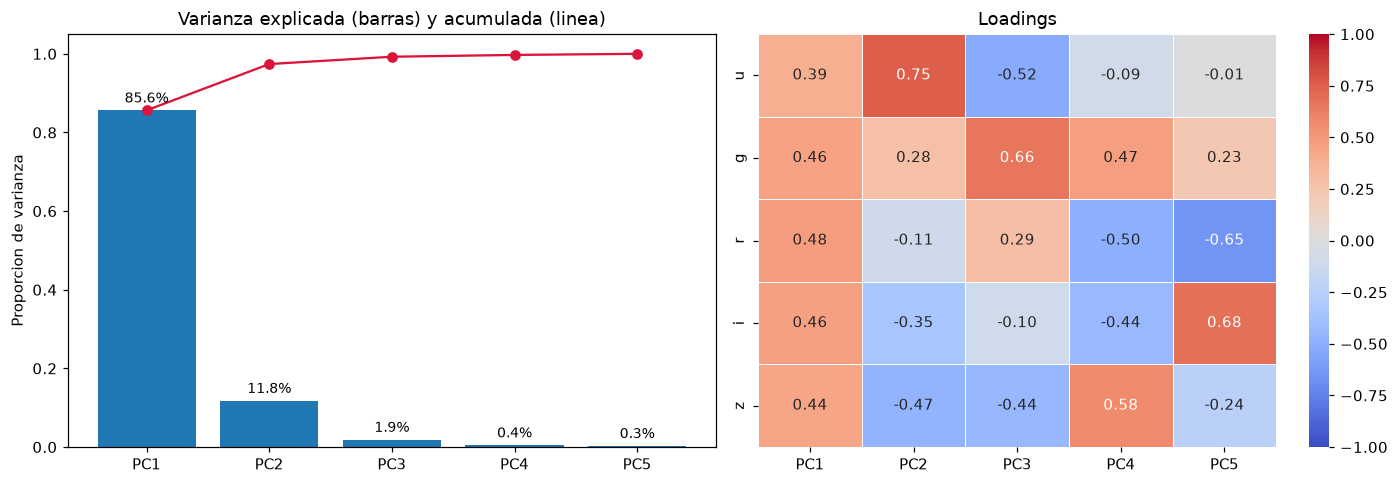

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = limpio[bandas].to_numpy()
escalador = StandardScaler()
X_esc = escalador.fit_transform(X)

pca = PCA()
Z = pca.fit_transform(X_esc)

varianza = pd.DataFrame({
    'varianza_explicada': pca.explained_variance_ratio_.round(4),
    'acumulada': np.cumsum(pca.explained_variance_ratio_).round(4),
}, index=[f'PC{i+1}' for i in range(len(bandas))])
display(varianza)

loadings = pd.DataFrame(pca.components_.T, index=bandas,
                        columns=[f'PC{i+1}' for i in range(len(bandas))])
print('Loadings: peso de cada banda dentro de cada componente')
display(loadings.round(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(varianza.index, varianza['varianza_explicada'])
ax[0].plot(varianza.index, varianza['acumulada'], color='crimson', marker='o')
ax[0].set_ylabel('Proporcion de varianza')
ax[0].set_title('Varianza explicada (barras) y acumulada (linea)')
for i, v in enumerate(varianza['varianza_explicada']):
    ax[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=9)

sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            ax=ax[1], linewidths=0.5)
ax[1].set_title('Loadings')
plt.tight_layout()
plt.show()


### P1.1: la varianza no es lo mismo que la utilidad (refinamiento)

El primer componente se lleva casi toda la varianza y la conclusion automatica seria quedarse con el y descartar el resto. Antes de hacerlo conviene mirar **que mide** cada componente, porque PCA ordena por dispersion y la dispersion no tiene por que coincidir con lo que interesa.

Los loadings de PC1 son todos positivos y de tamano parecido: es esencialmente un promedio de las cinco bandas, es decir cuanto brilla el objeto en conjunto. Y el brillo aparente depende sobre todo de que tan lejos y que tan luminoso es, no de que tipo es.

PC2 tiene los loadings con **signos opuestos**: positivo en las bandas azules, negativo en las rojas. Eso es una diferencia entre bandas, y una diferencia entre bandas es lo que en astronomia se llama un **color**. El color describe la forma del espectro, que si depende de la naturaleza del objeto.

Es una interpretacion de los pesos, no una medicion. Se puede poner a prueba comparando la varianza de cada componente contra su informacion mutua con la etiqueta apartada.


,varianza_explicada,informacion_mutua,ranking_varianza,ranking_informacion
PC1,0.8563,0.0677,1,4
PC2,0.1177,0.2942,2,1
PC3,0.0186,0.0800,3,3
PC4,0.0045,0.0861,4,2
PC5,0.0028,0.0412,5,5


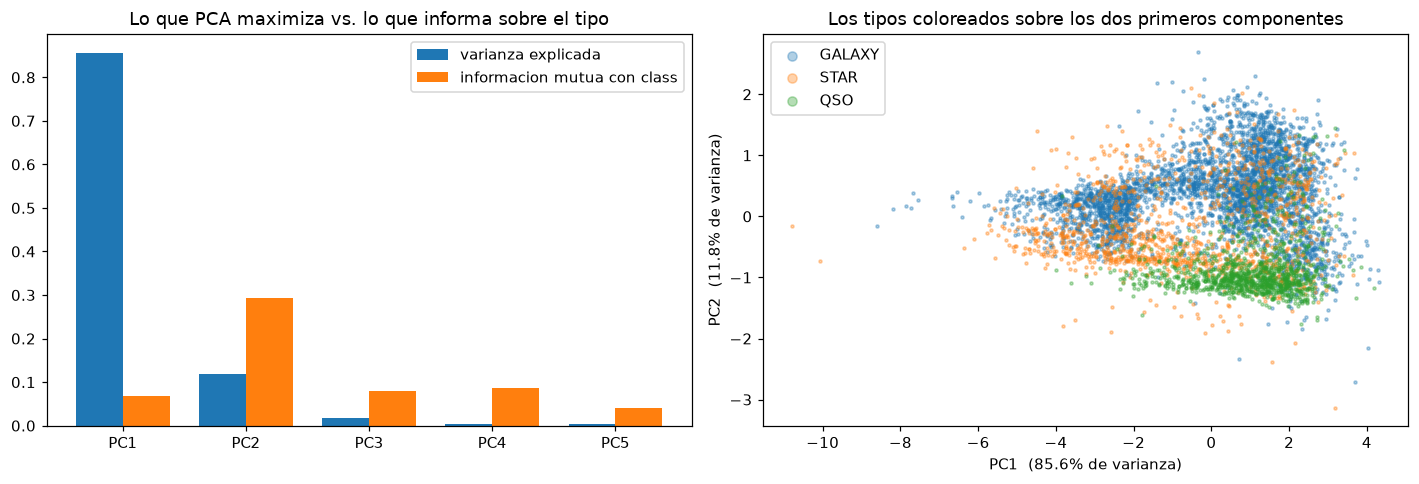

In [7]:
mi_componentes = mutual_info_classif(Z, etiqueta_limpia, random_state=0)

diagnostico = pd.DataFrame({
    'varianza_explicada': pca.explained_variance_ratio_.round(4),
    'informacion_mutua': mi_componentes.round(4),
}, index=[f'PC{i+1}' for i in range(len(bandas))])
diagnostico['ranking_varianza'] = diagnostico['varianza_explicada'].rank(ascending=False).astype(int)
diagnostico['ranking_informacion'] = diagnostico['informacion_mutua'].rank(ascending=False).astype(int)
display(diagnostico)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(bandas))
ancho = 0.38
ax[0].bar(x - ancho/2, diagnostico['varianza_explicada'], ancho, label='varianza explicada')
ax[0].bar(x + ancho/2, diagnostico['informacion_mutua'], ancho, label='informacion mutua con class')
ax[0].set_xticks(x); ax[0].set_xticklabels(diagnostico.index)
ax[0].legend()
ax[0].set_title('Lo que PCA maximiza vs. lo que informa sobre el tipo')

muestra = np.random.default_rng(0).choice(len(Z), 6000, replace=False)
for tipo, color in zip(['GALAXY', 'STAR', 'QSO'], ['tab:blue', 'tab:orange', 'tab:green']):
    m = etiqueta_limpia.iloc[muestra].to_numpy() == tipo
    ax[1].scatter(Z[muestra][m, 0], Z[muestra][m, 1], s=4, alpha=0.35, label=tipo, color=color)
ax[1].set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]:.1%} de varianza)')
ax[1].set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]:.1%} de varianza)')
ax[1].legend(markerscale=3)
ax[1].set_title('Los tipos coloreados sobre los dos primeros componentes')
plt.tight_layout()
plt.show()


### Cierre de P1

**Redundancia.** Dos componentes conservan mas del 97% de la varianza de las cinco bandas. La compresion es enorme y confirma lo que la matriz de correlacion ya sugeria: las cinco bandas no son cinco mediciones independientes, son cinco muestras de la misma curva.

**El orden de PCA no coincide con el orden de utilidad.** PC1 acapara la varianza y es el **penultimo** en informacion mutua. PC2, con una fraccion de la varianza, informa varias veces mas. Y PC3 y PC4, que juntos no llegan al 3% de la varianza, tambien le ganan a PC1. Quedarse con el primer componente por ser el primero habria tirado casi toda la senal util.

**De donde salio esa informacion.** PC2 informa mas que cualquiera de las cinco bandas por separado, y es solo una combinacion lineal de esas mismas cinco. PCA no puede crear informacion: lo que hizo fue **reorganizarla**. La informacion sobre el tipo de objeto no estaba en ninguna banda individual sino en las **diferencias entre ellas**, y cada banda por si sola queda dominada por el factor de brillo que todas comparten. Al construir un eje que resta bandas azules menos rojas, ese factor comun se cancela y queda expuesto lo que estaba repartido entre las cinco. Estaba ahi todo el tiempo, pero invisible mirando las columnas de a una.

Eso tiene una consecuencia practica: **el brillo total estorba**. Es la direccion de mayor varianza y no distingue tipos de objeto, asi que domina cualquier distancia euclidiana que se calcule sobre estos componentes. Un algoritmo que agrupe por distancia sobre PC1 va a separar objetos brillantes de debiles, que es una particion real pero trivial.

Queda una alternativa por probar: construir los colores directamente, restando bandas contiguas, en vez de esperar a que PCA los descubra. Se compara mas adelante.


## P2: que forma tienen los grupos, y cuanto cambia usar K-medias o mezcla gaussiana

Los dos algoritmos buscan grupos, pero parten de supuestos distintos.

**K-medias** coloca k centroides, asigna cada punto al mas cercano por distancia euclidiana y recalcula cada centroide como la media de su grupo, repitiendo hasta que nadie cambie. Como la distancia euclidiana trata todas las direcciones por igual, el metodo asume grupos **esfericos**, de tamano parecido, y solo puede separarlos con fronteras rectas. Cada punto queda asignado a un solo grupo, sin matices.

**La mezcla gaussiana** cambia cada centroide por una campana completa: una media, una **matriz de covarianza** que describe su forma y orientacion, y un **peso** que permite que los grupos tengan tamanos distintos. La pertenencia deja de ser todo o nada y pasa a ser una probabilidad repartida entre las campanas. Al medir con la covarianza de cada grupo en vez de con distancia euclidiana, una direccion en la que un grupo se estira mucho "cuenta menos" que una en la que es estrecho.

Esa flexibilidad cuesta parametros: en d dimensiones, K-medias guarda d numeros por grupo y una covarianza completa guarda d(d+1)/2 mas. Con 100 000 objetos eso no es problema aqui.

Para comparar hacen falta dos decisiones previas: cuantos componentes de PCA conservar y cuantos grupos buscar. Ninguna la resuelven los algoritmos solos.

### Como se va a medir

Se usan dos criterios que responden preguntas distintas:

- **Silhouette**, criterio **interno**: que tan compacto y separado quedo cada grupo, calculado con los mismos datos que se agruparon. No necesita etiqueta, pero premia la geometria que el propio algoritmo busca.
- **AMI**, informacion mutua ajustada, criterio **externo**: cuanta informacion comparten la particion hallada y los tipos reales. Vale 1 si coinciden y 0 si el parecido es el esperable por casualidad. Es importante que sea **ajustada**: la version cruda crece sola al aumentar el numero de grupos, asi que sin corregir un algoritmo pareceria mejor solo por partir mas fino.

El AMI usa la etiqueta apartada, pero **despues** de agrupar y solo para evaluar. Ningun modelo la ve durante el ajuste.

El silhouette es costoso porque compara cada punto contra todos los demas, asi que se calcula siempre sobre una **muestra de 10 000 objetos** fija.


Cuantos componentes conservar, con k=3 fijo:


,varianza_acumulada,ami_kmedias,ami_gmm
componentes,,,
2,0.9740,0.0474,0.0584
3,0.9926,0.0473,0.2434
4,0.9972,0.0472,0.0548


,inercia_kmedias,silhouette_kmedias,bic_gmm
k,,,
2,174889,0.5607,599810
3,126208,0.3800,570165
4,96139,0.3897,536090
5,78661,0.3657,531407
6,65111,0.3725,529664
7,56801,0.3453,517948
8,49902,0.3593,515240


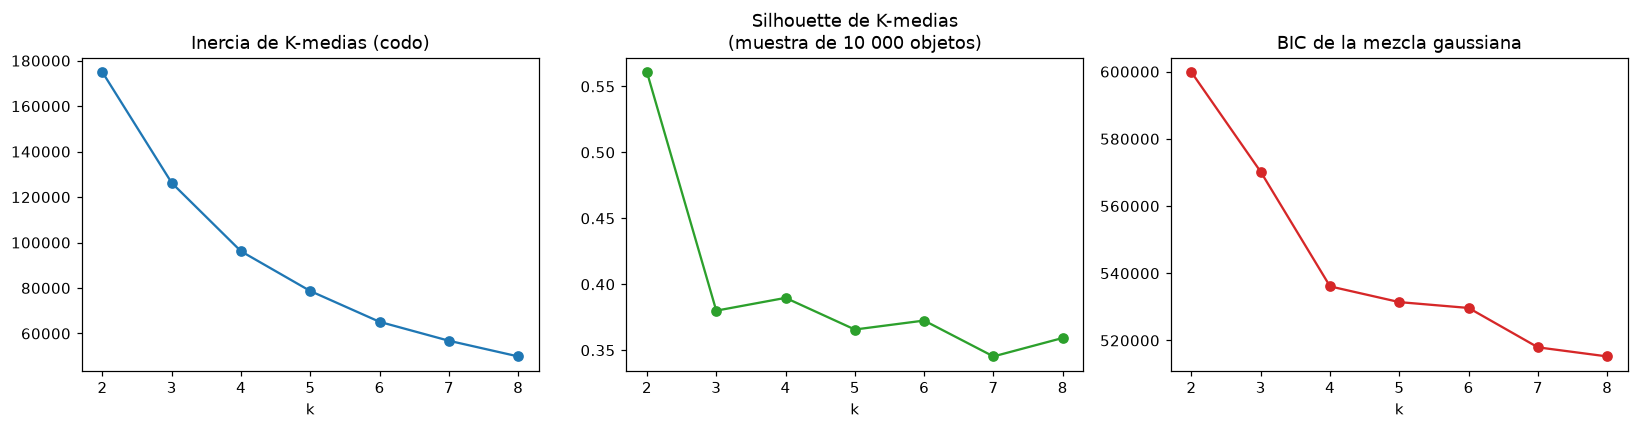

In [8]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_mutual_info_score

sub = np.random.default_rng(0).choice(len(Z), 10000, replace=False)

barrido_componentes = []
for nc in [2, 3, 4]:
    Zc = Z[:, :nc]
    km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Zc)
    gm = GaussianMixture(n_components=3, covariance_type='full', random_state=0, n_init=3).fit(Zc)
    barrido_componentes.append({
        'componentes': nc,
        'varianza_acumulada': round(float(np.cumsum(pca.explained_variance_ratio_)[nc-1]), 4),
        'ami_kmedias': round(adjusted_mutual_info_score(etiqueta_limpia, km.labels_), 4),
        'ami_gmm': round(adjusted_mutual_info_score(etiqueta_limpia, gm.predict(Zc)), 4),
    })
print('Cuantos componentes conservar, con k=3 fijo:')
display(pd.DataFrame(barrido_componentes).set_index('componentes'))

n_comp = 3
Z_red = Z[:, :n_comp]

busqueda = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Z_red)
    gm = GaussianMixture(n_components=k, covariance_type='full', random_state=0, n_init=3).fit(Z_red)
    busqueda.append({
        'k': k,
        'inercia_kmedias': round(km.inertia_),
        'silhouette_kmedias': round(silhouette_score(Z_red[sub], km.labels_[sub]), 4),
        'bic_gmm': round(gm.bic(Z_red)),
    })

busqueda = pd.DataFrame(busqueda).set_index('k')
display(busqueda)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(busqueda.index, busqueda['inercia_kmedias'], marker='o')
ax[0].set_xlabel('k'); ax[0].set_title('Inercia de K-medias (codo)')
ax[1].plot(busqueda.index, busqueda['silhouette_kmedias'], marker='o', color='tab:green')
ax[1].set_xlabel('k'); ax[1].set_title('Silhouette de K-medias\n(muestra de 10 000 objetos)')
ax[2].plot(busqueda.index, busqueda['bic_gmm'], marker='o', color='tab:red')
ax[2].set_xlabel('k'); ax[2].set_title('BIC de la mezcla gaussiana')
plt.tight_layout()
plt.show()


### Cuantos componentes y cuantos grupos

El criterio habitual para elegir componentes es la varianza acumulada, y por ese criterio bastarian dos: ya superan el 97%.

La tabla dice otra cosa. El tercer componente aporta menos de dos puntos de varianza y **multiplica por cuatro** el parecido con los tipos reales. El cuarto aporta medio punto y lo **derrumba**. Ni el tamano del aporte ni su direccion se pueden anticipar desde la varianza.

Y hay algo peor: **la columna que me dice que tres es la buena es el AMI, que se calcula contra la etiqueta**. En un problema realmente sin etiquetar yo solo tendria la varianza, elegiria dos, y nunca sabria lo que me perdi. La configuracion que da el mejor resultado se eligio mirando la respuesta.

Se trabaja con tres, pero eso convierte cualquier conclusion que dependa de ese numero en fragil, y hay que decirlo cuando llegue el momento.

Con el numero de grupos pasa algo parecido: ninguno de los tres criterios apunta a k=3. La inercia baja sin quiebre, el silhouette es maximo en **k=2**, y el BIC sigue bajando hasta el final del rango. **La estructura geometrica de estos datos no coincide con la particion en tres tipos de objeto.** Se usan tres porque la pregunta lo pide, no porque los datos lo indiquen.


### P2.1: se cumple la prediccion de que el brillo estorba?

El cierre de P1 dejo una prediccion sin comprobar: como PC1 mide brillo y concentra casi toda la varianza, deberia dominar cualquier distancia euclidiana y arrastrar a K-medias a partir por brillo en vez de por tipo de objeto. PC1 se conservo justamente para poder comprobarlo.

Hay dos formas de verlo. Mirar **donde estan los centros**: si K-medias solo separa a lo largo de PC1, sus centroides estaran muy distanciados en ese eje y practicamente pegados en los demas. Y probar **que pasa al entregarle distintos subconjuntos de ejes**: si el problema es PC1, quitarlo deberia mejorar el resultado en vez de empeorarlo, que es lo contrario de lo que uno esperaria de quitar el componente con mas varianza.


In [9]:
km_base = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Z_red)
gm_base = GaussianMixture(n_components=3, covariance_type='full', random_state=0, n_init=3).fit(Z_red)

ejes = [f'PC{i+1}' for i in range(n_comp)]
centros_km = pd.DataFrame(km_base.cluster_centers_, columns=ejes)
centros_gm = pd.DataFrame(gm_base.means_, columns=ejes)

print('Centroides de K-medias:')
display(centros_km.round(2))
print('Medias de la mezcla gaussiana:')
display(centros_gm.round(2))

separacion = pd.DataFrame({
    'K-medias': (centros_km.max() - centros_km.min()).round(2),
    'Mezcla gaussiana': (centros_gm.max() - centros_gm.min()).round(2),
})
print('Cuanto separa cada eje a los grupos (rango entre centros):')
display(separacion)

subconjuntos = [([0], 'PC1'), ([1], 'PC2'), ([2], 'PC3'),
                ([0, 1], 'PC1+PC2'), ([0, 2], 'PC1+PC3'), ([1, 2], 'PC2+PC3'),
                ([0, 1, 2], 'PC1+PC2+PC3')]
por_subconjunto = []
for indices, nombre in subconjuntos:
    Zs = Z[:, indices]
    km_s = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Zs)
    gm_s = GaussianMixture(n_components=3, covariance_type='full', random_state=0, n_init=3).fit(Zs)
    gd_s = GaussianMixture(n_components=3, covariance_type='diag', random_state=0, n_init=3).fit(Zs)
    por_subconjunto.append({
        'ejes_usados': nombre,
        'varianza_incluida': round(float(pca.explained_variance_ratio_[indices].sum()), 4),
        'ami_kmedias': round(adjusted_mutual_info_score(etiqueta_limpia, km_s.labels_), 4),
        'ami_gmm_diag': round(adjusted_mutual_info_score(etiqueta_limpia, gd_s.predict(Zs)), 4),
        'ami_gmm_full': round(adjusted_mutual_info_score(etiqueta_limpia, gm_s.predict(Zs)), 4),
    })
print('Que pasa segun que ejes se le entreguen a cada algoritmo:')
display(pd.DataFrame(por_subconjunto).set_index('ejes_usados'))


Centroides de K-medias:


,PC1,PC2,PC3
0,1.80,-0.02,0.01
1,-2.97,-0.04,0.01
2,-0.09,0.07,-0.03


Medias de la mezcla gaussiana:


,PC1,PC2,PC3
0,0.83,-0.94,-0.09
1,-2.70,0.03,0.00
2,1.21,0.50,0.04


Cuanto separa cada eje a los grupos (rango entre centros):


,K-medias,Mezcla gaussiana
PC1,4.76,3.91
PC2,0.11,1.44
PC3,0.04,0.13


Que pasa segun que ejes se le entreguen a cada algoritmo:


,varianza_incluida,ami_kmedias,ami_gmm_diag,ami_gmm_full
ejes_usados,,,,
PC1,0.8563,0.0478,0.0456,0.0456
PC2,0.1177,0.2014,0.2012,0.2012
PC3,0.0186,0.0302,0.0268,0.0268
PC1+PC2,0.9740,0.0474,0.0529,0.0584
PC1+PC3,0.8749,0.0484,0.0427,0.0499
PC2+PC3,0.1363,0.2093,0.2095,0.1403
PC1+PC2+PC3,0.9926,0.0473,0.1441,0.2434


### P2.2: que pasa al restringir la forma de las campanas

Si la diferencia entre los dos algoritmos esta en el supuesto sobre la forma, la manera de comprobarlo es apretar ese supuesto poco a poco. `covariance_type` permite exactamente eso, en cuatro variantes de menor a mayor libertad:

- **`spherical`**: campanas redondas, un solo numero de ancho por grupo. Es el supuesto de K-medias.
- **`tied`**: elipses con cualquier forma e inclinacion, pero **la misma para todos los grupos**.
- **`diag`**: cada grupo con su propia forma, pero solo elipses alineadas a los ejes, sin inclinacion.
- **`full`**: cada grupo con su propia elipse, con forma e inclinacion libres.

Si la forma no importara en estos datos, las cuatro darian resultados parecidos.


,parametros_covarianza,bic,silhouette_muestra,ami_con_class
covariance_type,,,,
spherical,14,783501,0.3823,0.0490
tied,17,660495,0.3271,0.0750
diag,20,604604,0.3025,0.1441
full,29,570165,0.3619,0.2434


K-medias como referencia (no comparte familia de parametros ni verosimilitud, por eso va aparte):


,silhouette_muestra,ami_con_class
K-medias,0.38,0.0473


Mejor segun silhouette (interno): spherical
Mejor segun AMI (externo):        full
Peor segun AMI (externo):         K-medias


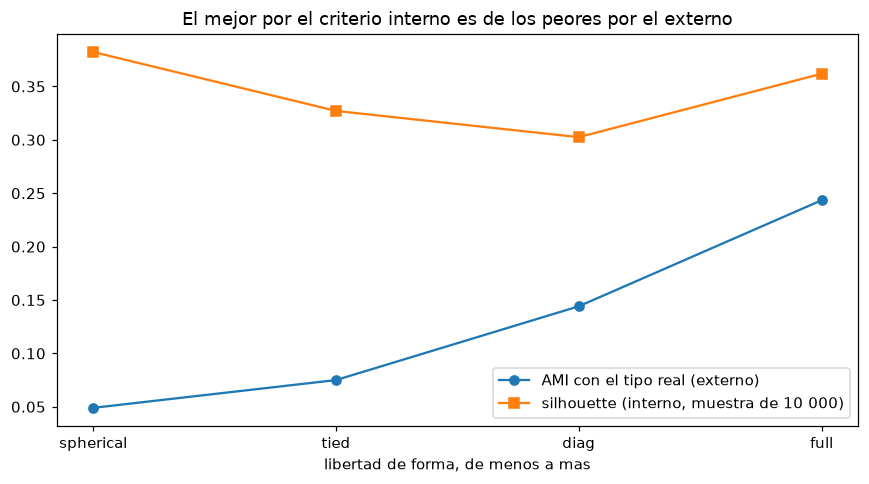

In [10]:
formas = ['spherical', 'tied', 'diag', 'full']
comparacion_forma = []
for forma in formas:
    gm = GaussianMixture(n_components=3, covariance_type=forma, random_state=0, n_init=3).fit(Z_red)
    etiquetas_gm = gm.predict(Z_red)
    comparacion_forma.append({
        'covariance_type': forma,
        'parametros_covarianza': int(gm._n_parameters()),
        'bic': round(gm.bic(Z_red)),
        'silhouette_muestra': round(silhouette_score(Z_red[sub], etiquetas_gm[sub]), 4),
        'ami_con_class': round(adjusted_mutual_info_score(etiqueta_limpia, etiquetas_gm), 4),
    })
tabla_forma = pd.DataFrame(comparacion_forma).set_index('covariance_type')
display(tabla_forma)

referencia_km = pd.DataFrame({
    'silhouette_muestra': [round(silhouette_score(Z_red[sub], km_base.labels_[sub]), 4)],
    'ami_con_class': [round(adjusted_mutual_info_score(etiqueta_limpia, km_base.labels_), 4)],
}, index=['K-medias'])
print('K-medias como referencia (no comparte familia de parametros ni verosimilitud, por eso va aparte):')
display(referencia_km)

todos = pd.concat([tabla_forma[['silhouette_muestra', 'ami_con_class']], referencia_km])
print(f"Mejor segun silhouette (interno): {todos['silhouette_muestra'].idxmax()}")
print(f"Mejor segun AMI (externo):        {todos['ami_con_class'].idxmax()}")
print(f"Peor segun AMI (externo):         {todos['ami_con_class'].idxmin()}")

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(formas))
ax.plot(x, tabla_forma.loc[formas, 'ami_con_class'], marker='o', label='AMI con el tipo real (externo)')
ax.plot(x, tabla_forma.loc[formas, 'silhouette_muestra'], marker='s', label='silhouette (interno, muestra de 10 000)')
ax.set_xticks(x); ax.set_xticklabels(formas)
ax.set_xlabel('libertad de forma, de menos a mas')
ax.legend()
ax.set_title('El mejor por el criterio interno es de los peores por el externo')
plt.tight_layout()
plt.show()


### P2.3: que le da a la mezcla gaussiana su unica ventaja

La mezcla gaussiana alcanza su mejor resultado **solo con los tres ejes juntos**, y ninguna pareja se le acerca. Si no se puede explicar que aporta esa combinacion, el numero es justo del tipo que hay que mirar con desconfianza.

La comparacion de formas permite aislarlo, porque las cuatro variantes se distinguen en **tres** libertades independientes: si cada grupo tiene su propia matriz, si dentro de cada matriz cada eje puede tener su propio ancho, y si la elipse puede inclinarse.

| variante | matriz propia por grupo | ancho propio por eje | inclinacion |
|---|---|---|---|
| `spherical` | si | no, uno solo | no |
| `tied` | no, una compartida | si | si |
| `diag` | si | si | no |
| `full` | si | si | si |

Cruzando esas tres columnas contra los resultados se puede ver cual manda. Hay dos contrastes que conviene mirar de frente en vez de esquivarlos: `tied` **si** permite inclinacion y aun asi rinde menos que `diag`, que la prohibe; y `spherical` y `diag` comparten dos de las tres libertades y aun asi se separan por mucho.

Ademas, como toda esta seccion cuelga de un solo valor, hay que comprobar que no venga de una inicializacion afortunada.


In [11]:
libertades = {
    'spherical': ('si', 'no, uno solo', 'no'),
    'tied': ('no, compartida', 'si', 'si'),
    'diag': ('si', 'si', 'no'),
    'full': ('si', 'si', 'si'),
}
desglose = []
geometria = []
for forma, (propia, por_eje, inclinacion) in libertades.items():
    gm_f = GaussianMixture(n_components=3, covariance_type=forma, random_state=0, n_init=3).fit(Z_red)
    desglose.append({
        'covariance_type': forma,
        'matriz_propia_por_grupo': propia,
        'ancho_propio_por_eje': por_eje,
        'inclinacion': inclinacion,
        'ami_con_class': round(adjusted_mutual_info_score(etiqueta_limpia, gm_f.predict(Z_red)), 4),
    })
    grupos_a_describir = ['compartida'] if forma == 'tied' else list(range(3))
    for k in grupos_a_describir:
        if forma == 'tied':
            C = gm_f.covariances_
        elif forma == 'spherical':
            C = np.eye(n_comp) * gm_f.covariances_[k]
        elif forma == 'diag':
            C = np.diag(gm_f.covariances_[k])
        else:
            C = gm_f.covariances_[k]
        valores = np.sort(np.linalg.eigvalsh(C))[::-1]
        alargamiento = float(np.sqrt(valores[0] / valores[-1]))
        if alargamiento < 1.01:
            angulo = np.nan
        else:
            vectores = np.linalg.eigh(C)[1][:, np.argsort(np.linalg.eigvalsh(C))[::-1]]
            angulo = round(float(np.degrees(np.arccos(abs(vectores[0, 0])))), 1)
        anchos = np.sqrt(np.diag(C))
        geometria.append({
            'covariance_type': forma,
            'campana': k,
            'ancho_PC1': round(float(anchos[0]), 2),
            'ancho_PC2': round(float(anchos[1]), 2),
            'alargamiento': round(alargamiento, 1),
            'inclinacion_vs_PC1_grados': angulo,
        })

print('Las tres libertades por separado:')
display(pd.DataFrame(desglose).set_index('covariance_type'))

print('Forma que toma cada campana en cada variante.')
print('`tied` aparece con una sola fila porque por definicion las tres campanas comparten la misma matriz.')
print('El angulo queda vacio cuando la campana es esferica: una esfera no tiene orientacion.')
display(pd.DataFrame(geometria).set_index(['covariance_type', 'campana']))

estabilidad = []
for semilla in range(8):
    gm_s = GaussianMixture(n_components=3, covariance_type='full', random_state=semilla, n_init=3).fit(Z_red)
    km_s = KMeans(n_clusters=3, n_init=10, random_state=semilla).fit(Z[:, [1, 2]])
    estabilidad.append({
        'semilla': semilla,
        'ami_gmm_tres_ejes': round(adjusted_mutual_info_score(etiqueta_limpia, gm_s.predict(Z_red)), 4),
        'ami_kmedias_PC2_PC3': round(adjusted_mutual_info_score(etiqueta_limpia, km_s.labels_), 4),
    })
print('Sensibilidad a la inicializacion:')
display(pd.DataFrame(estabilidad).set_index('semilla').describe().loc[['mean', 'std', 'min', 'max']].round(4))


Las tres libertades por separado:


,matriz_propia_por_grupo,ancho_propio_por_eje,inclinacion,ami_con_class
covariance_type,,,,
spherical,si,"no, uno solo",no,0.0490
tied,"no, compartida",si,si,0.0750
diag,si,si,no,0.1441
full,si,si,si,0.2434


Forma que toma cada campana en cada variante.
`tied` aparece con una sola fila porque por definicion las tres campanas comparten la misma matriz.
El angulo queda vacio cuando la campana es esferica: una esfera no tiene orientacion.


ancho_PC1  ancho_PC2  alargamiento  inclinacion_vs_PC1_grados
covariance_type campana                                                                  
spherical       0                0.68       0.68           1.0                        NaN
                1                0.65       0.65           1.0                        NaN
                2                0.68       0.68           1.0                        NaN
tied            compartida       1.10       0.62           4.5                        3.3
diag            0                0.91       0.77           2.0                        0.0
                1                1.12       0.41          15.4                        0.0
                2                1.42       0.77          10.1                        0.0
full            0                1.35       0.26           9.7                        2.8
                1                1.22       0.43          16.7                        5.4
                2                1.02       0.62           2.6                       13.4

Sensibilidad a la inicializacion:


,ami_gmm_tres_ejes,ami_kmedias_PC2_PC3
mean,0.2434,0.2092
std,0.0001,0.0002
min,0.2432,0.2090
max,0.2435,0.2093


#### Que dicen esas tablas

**La primera hipotesis era la relacion entre PC1 y PC3, y es falsa**: ese par por si solo da un resultado pesimo.

**Las tres libertades no pesan igual y ninguna sola alcanza.**

- De `spherical` a `diag` el resultado casi se triplica, y lo unico que cambia es poder darle **un ancho distinto a cada eje**. En la tabla de geometria se ve: `spherical` deja tres esferas de tamano casi igual, `diag` las estira hasta quince a uno. Ser largo en un eje y estrecho en otro es lo que permite que una campana deje de reaccionar a la dispersion del brillo.
- `tied` tiene ancho por eje **e** inclinacion, y queda casi al fondo. Le falta lo primero: una sola forma compartida por los tres grupos no sirve aunque sea flexible.
- De `diag` a `full` casi se duplica otra vez, y lo unico que se agrega es la **inclinacion**. Pero la inclinacion sola tampoco compra nada, porque `tied` tambien esta inclinada y va al fondo. Solo rinde cuando **cada grupo tiene la suya**.

**El detalle fino no quedo aislado.** Los anchos en PC1 de las tres campanas son parecidos; lo que difiere entre grupos es cuan estrechas son en los otros ejes. Por que ese reparto concreto de formas mas unos pocos grados de giro rinde el doble es algo que este cuaderno **muestra pero no explica**.

**Y la ventaja es modesta.** Casi toda la senal esta en PC2. Sumarle PC3 la mantiene. Agregar PC1 hunde a K-medias hasta casi cero y le quita un tercio a `diag`; el unico que lo encaja es `full`, que termina apenas por encima del mejor resultado obtenido sin PC1. La covarianza completa no descubre estructura que los demas no vean: **encaja el estorbo de PC1 mejor que nadie**, y necesita las tres dimensiones para hacerlo. Veintinueve parametros para llegar donde llega descartar un componente a mano.

**No es un accidente de la inicializacion.** Con ocho semillas el resultado varia en milesimas. Lo fragil es la eleccion de ejes, no el ajuste.


### Cierre de P2

**La prediccion se cumplio.** Los centroides de K-medias se separan casi cinco unidades en PC1 y una decima en PC2, y agrupar con **solo PC1** da el mismo resultado que con los tres ejes. K-medias no usaba los otros: partia el catalogo en objetos brillantes, medios y debiles. Una particion real e inutil para la pregunta.

No es culpa del algoritmo sino del supuesto. La distancia euclidiana trata todas las direcciones por igual, asi que manda la de mayor dispersion, y esa resulta ser el brillo.

**K-medias no era incapaz, estaba lastrado.** Con solo PC2 su resultado se multiplica por cuatro; con PC2 y PC3 le gana a la mezcla gaussiana sobre ese mismo par, aunque queda por debajo del mejor global.

**Ninguna ventaja es estable.** La de la mezcla gaussiana existe sobre los tres componentes y desaparece si se quita un eje o se agrega el cuarto. La de K-medias existe solo donde PC1 no esta. El resultado depende tanto de que ejes se entregan como de que algoritmo los procesa.

**Restringir la forma degrada de manera ordenada**, y `spherical` da practicamente lo mismo que K-medias: es la teoria confirmada, K-medias es una mezcla gaussiana esferica con asignacion dura. Las dos quedan al fondo.

**El silhouette no acompana.** Su mejor configuracion es `spherical`, que esta entre las peores por validacion externa. Premia grupos compactos, que es la geometria que las campanas esfericas producen por construccion, asi que favorece a la configuracion que agrupaba por la variable equivocada. Un criterio interno mide que tan bien quedo la particion **segun su propia definicion de bien**, y aqui esa definicion no coincide con la pregunta.


## P3: se parecen los grupos hallados a los tipos reales?

Hasta aqui la comparacion fue entre variantes del mismo algoritmo sobre la misma representacion. Falta probar una representacion distinta del mismo dato y preguntar si algo de esto recupera la estructura real.

En vez de esperar a que PCA aisle el brillo en un componente, se puede cancelar directamente restando bandas contiguas: `u-g`, `g-r`, `r-i`, `i-z`. Cada resta elimina **por construccion** el factor comun que en P2.1 se vio dominando a K-medias. Es como trabaja la astronomia.

La comparacion no es del todo pareja y conviene decirlo: son cinco bandas contra cuatro colores, asi que el punto de partida tiene una dimension menos. Lo que si se mantiene igual es el resto del procedimiento: sobre ambas representaciones se estandariza, se aplica PCA, se conservan tres componentes y se corren los mismos dos algoritmos con los mismos parametros.


variables_de_entrada  varianza_PC1  silhouette_muestra  ami_con_class
representacion    modelo                                                                                 
PCA sobre bandas  K-medias                             5         0.856              0.3800         0.0473
                  Mezcla gaussiana                     5         0.856              0.3619         0.2434
PCA sobre colores K-medias                             4         0.473              0.3876         0.1775
                  Mezcla gaussiana                     4         0.473              0.2787         0.1243

Cuanto separa cada eje a los centroides de K-medias en cada representacion:


,PCA sobre bandas,PCA sobre colores
PC1,4.76,2.53
PC2,0.11,1.72
PC3,0.04,0.77


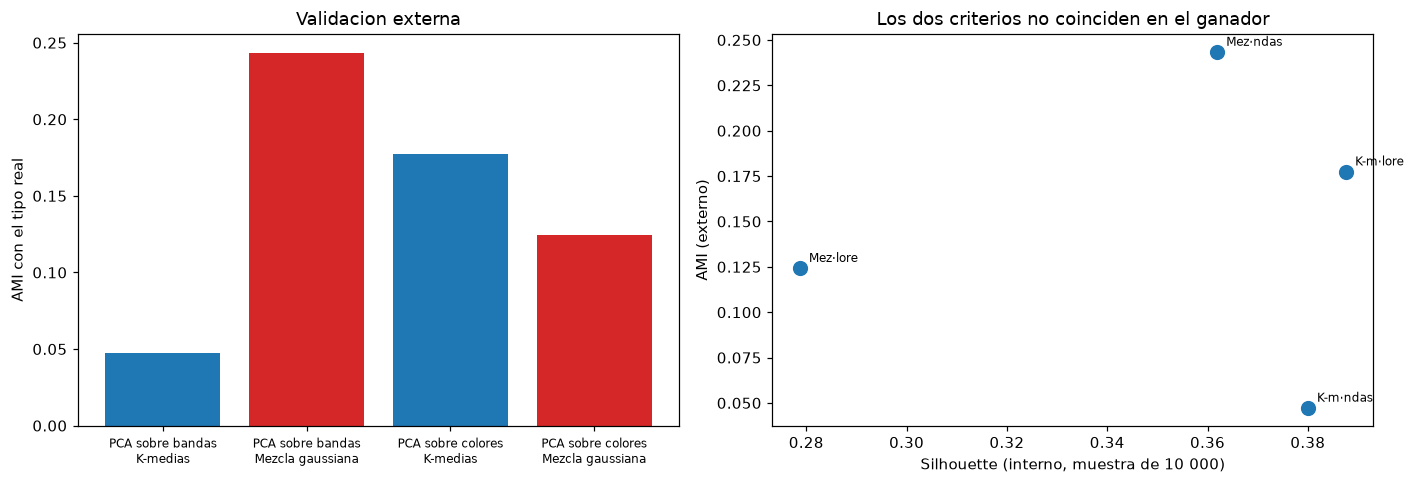

In [12]:
colores_astro = pd.DataFrame({
    'u_g': limpio['u'] - limpio['g'],
    'g_r': limpio['g'] - limpio['r'],
    'r_i': limpio['r'] - limpio['i'],
    'i_z': limpio['i'] - limpio['z'],
})

representaciones = {
    'PCA sobre bandas': limpio[bandas],
    'PCA sobre colores': colores_astro,
}

resultados = []
espacios = {}
dispersion_centros = {}
for nombre, matriz in representaciones.items():
    Xr = StandardScaler().fit_transform(matriz)
    pca_r = PCA().fit(Xr)
    Zr = pca_r.transform(Xr)[:, :3]
    espacios[nombre] = Zr
    km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Zr)
    gm = GaussianMixture(n_components=3, covariance_type='full', random_state=0, n_init=3).fit(Zr)
    centros = pd.DataFrame(km.cluster_centers_, columns=['PC1', 'PC2', 'PC3'])
    dispersion_centros[nombre] = (centros.max() - centros.min()).round(2)
    for modelo, etiquetas_pred in [('K-medias', km.labels_), ('Mezcla gaussiana', gm.predict(Zr))]:
        resultados.append({
            'representacion': nombre,
            'modelo': modelo,
            'variables_de_entrada': matriz.shape[1],
            'varianza_PC1': round(pca_r.explained_variance_ratio_[0], 3),
            'silhouette_muestra': round(silhouette_score(Zr[sub], etiquetas_pred[sub]), 4),
            'ami_con_class': round(adjusted_mutual_info_score(etiqueta_limpia, etiquetas_pred), 4),
        })

comparacion = pd.DataFrame(resultados).set_index(['representacion', 'modelo'])
display(comparacion)

print('Cuanto separa cada eje a los centroides de K-medias en cada representacion:')
display(pd.DataFrame(dispersion_centros))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
plano = comparacion.reset_index()
ax[0].bar(range(len(plano)), plano['ami_con_class'], color=['tab:blue', 'tab:red'] * 2)
ax[0].set_xticks(range(len(plano)))
ax[0].set_xticklabels(plano['representacion'] + '\n' + plano['modelo'], fontsize=8)
ax[0].set_ylabel('AMI con el tipo real')
ax[0].set_title('Validacion externa')

ax[1].scatter(plano['silhouette_muestra'], plano['ami_con_class'], s=80)
for _, fila in plano.iterrows():
    ax[1].annotate(f"{fila['modelo'][:3]}·{fila['representacion'][12:16]}",
                   (fila['silhouette_muestra'], fila['ami_con_class']), fontsize=8,
                   textcoords='offset points', xytext=(6, 4))
ax[1].set_xlabel('Silhouette (interno, muestra de 10 000)')
ax[1].set_ylabel('AMI (externo)')
ax[1].set_title('Los dos criterios no coinciden en el ganador')
plt.tight_layout()
plt.show()


### P3.1: donde acierta y donde falla el mejor de los cuatro

El AMI resume el parecido en un numero pero no dice **como** se equivoca. Para eso hace falta cruzar los grupos hallados contra los tipos reales y mirar la tabla: que grupo capturo que tipo, y cuales quedaron mezclados.

Se aprovecha ademas algo que solo tiene la mezcla gaussiana: la pertenencia blanda. Cada objeto trae una probabilidad por grupo, asi que se puede separar lo que el modelo asigno con seguridad de lo que asigno dudando.


Objetos por tipo real y grupo hallado:


grupo hallado,0,1,2
tipo real,,,
GALAXY,3486,18950,37009
QSO,15930,301,2730
STAR,6133,9130,6330


Por COLUMNA: de que esta hecho cada grupo hallado


grupo hallado,0,1,2
tipo real,,,
GALAXY,0.136,0.668,0.803
QSO,0.624,0.011,0.059
STAR,0.240,0.322,0.137


Por FILA: a donde fue a parar cada tipo real


grupo hallado,0,1,2
tipo real,,,
GALAXY,0.059,0.319,0.623
QSO,0.840,0.016,0.144
STAR,0.284,0.423,0.293


Fraccion del tipo que quedo en su grupo mayoritario:


,concentracion
tipo real,
GALAXY,0.623
QSO,0.840
STAR,0.423


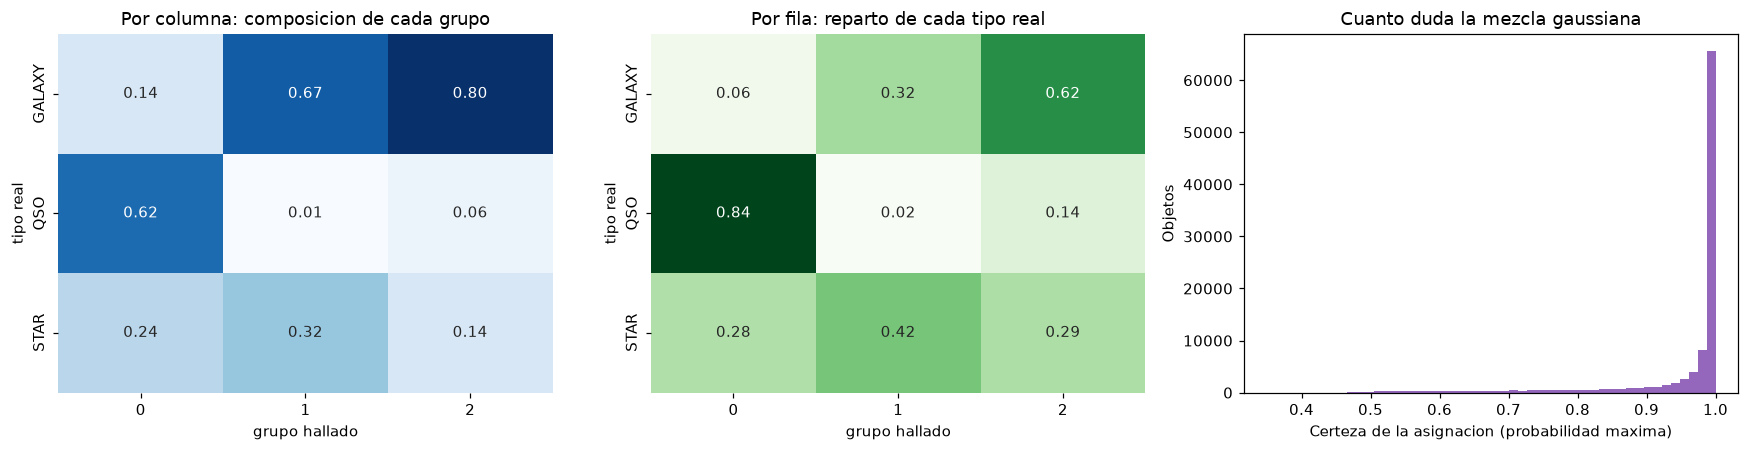

Objetos asignados con mas de 90% de certeza: 85429 de 99999 (85.4%)
AMI sobre el conjunto completo:              0.2434
AMI restringido a los asignados con certeza: 0.2890


In [13]:
Z_mejor = espacios['PCA sobre bandas']
gmm_final = GaussianMixture(n_components=3, covariance_type='full', random_state=0, n_init=3).fit(Z_mejor)
grupos = gmm_final.predict(Z_mejor)
responsabilidades = gmm_final.predict_proba(Z_mejor)
certeza = responsabilidades.max(axis=1)

cruce = pd.crosstab(etiqueta_limpia, grupos, rownames=['tipo real'], colnames=['grupo hallado'])
print('Objetos por tipo real y grupo hallado:')
display(cruce)

print('Por COLUMNA: de que esta hecho cada grupo hallado')
por_columna = (cruce / cruce.sum(axis=0)).round(3)
display(por_columna)

print('Por FILA: a donde fue a parar cada tipo real')
por_fila = cruce.div(cruce.sum(axis=1), axis=0).round(3)
display(por_fila)

concentracion = por_fila.max(axis=1)
print('Fraccion del tipo que quedo en su grupo mayoritario:')
display(concentracion.round(3).to_frame('concentracion'))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
sns.heatmap(por_columna, annot=True, fmt='.2f', cmap='Blues', ax=ax[0], cbar=False)
ax[0].set_title('Por columna: composicion de cada grupo')
sns.heatmap(por_fila, annot=True, fmt='.2f', cmap='Greens', ax=ax[1], cbar=False)
ax[1].set_title('Por fila: reparto de cada tipo real')
ax[2].hist(certeza, bins=50, color='tab:purple')
ax[2].set_xlabel('Certeza de la asignacion (probabilidad maxima)')
ax[2].set_ylabel('Objetos')
ax[2].set_title('Cuanto duda la mezcla gaussiana')
plt.tight_layout()
plt.show()

seguros = certeza > 0.9
print(f'Objetos asignados con mas de 90% de certeza: {int(seguros.sum())} de {len(certeza)} ({100*seguros.mean():.1f}%)')
print(f'AMI sobre el conjunto completo:              {adjusted_mutual_info_score(etiqueta_limpia, grupos):.4f}')
print(f'AMI restringido a los asignados con certeza: {adjusted_mutual_info_score(etiqueta_limpia[seguros], grupos[seguros]):.4f}')


### Cierre de P3

**Cancelar el brillo a mano cambia quien gana.** Con PCA sobre las bandas la mezcla gaussiana aventaja a K-medias; con los colores se da vuelta. La tabla de dispersion de centroides explica por que: en bandas los centros de K-medias se separan casi solo en un eje, en colores se reparten entre los tres. Al restar bandas desaparece la direccion que secuestraba las distancias.

Confirma lo de P2.3: **la ventaja de la mezcla gaussiana venia de neutralizar una direccion irrelevante, no de describir mejor los tipos.** Sin ese estorbo, la flexibilidad extra pasa a ser un costo, porque ajusta **densidad** y no separacion de clases. Se ve tambien dentro del espacio de bandas: sobre PC2 y PC3, la variante restringida iguala a K-medias y la completa se queda por detras.

Los colores tampoco son la mejor representacion: el mejor valor sigue siendo el de la mezcla gaussiana sobre los tres componentes de las bandas. Ninguno de los dos es solido, por lo ya dicho.

**Nada de esto recupera bien los tres tipos.** La vista por fila lo explica:

- Los **cuasares** se concentran mayoritariamente en un grupo. Es el unico tipo que el agrupamiento aisla.
- Las **galaxias** quedan repartidas entre dos, con mayoria clara en uno.
- Las **estrellas** se reparten entre los tres: el grupo que mas recibe se queda con algo mas del 40% y los otros con cerca del 30% cada uno. No hay ningun grupo que sea suyo. Mirando solo la composicion de cada grupo esto no se ve.

**El modelo esta seguro y equivocado.** Asigna la gran mayoria de los objetos con mas del 90% de certeza y aun asi el parecido con los tipos reales es bajo. La certeza mide distancia a una frontera, no acierto: un modelo puede estar convencidisimo de una particion que no corresponde a nada. **La confianza de un modelo no supervisado no es evidencia de acierto**, y sin la etiqueta apartada no habria forma de notarlo.

El AMI sube algo al restringirse a los objetos asignados con certeza, pero son conjuntos distintos y no comparan limpio. Solo sugiere que la certeza correlaciona algo con el acierto.

La lectura fisica es coherente: los tres tipos se distinguen sobre todo por su **distancia**, que se mide con el redshift y que salio del analisis por decision propia. Con cinco numeros de brillo, un cuasar destaca, pero una estrella cercana y una galaxia lejana pueden verse iguales.


## Respuestas

**P1. Cuanta redundancia hay entre las bandas y que significa cada componente.** Muchisima: dos componentes conservan mas del 97% de la varianza de las cinco. Los pesos permiten leerlos: el primero es un promedio de las cinco bandas, es decir el brillo global, y el segundo opone bandas azules contra rojas, que es lo que en astronomia se llama un color. Lo importante es que ese orden **no coincide con el orden de utilidad**: el componente que acapara la varianza es de los que menos informan sobre el tipo de objeto y el segundo informa varias veces mas. PCA no crea informacion, la reorganiza: la senal estaba en las diferencias entre bandas y ninguna banda por separado la mostraba, porque todas quedan dominadas por el brillo que comparten.

**P2. Que forma tienen los grupos y cuanto cambia el algoritmo.** Menos de lo que parecia al principio. K-medias mide con distancia euclidiana, manda la direccion de mayor dispersion, y esa direccion es el brillo: termina partiendo el catalogo en objetos brillantes, medios y debiles. Se comprobo mirando los centroides, separados casi solo en el primer componente, y verificando que agrupar con ese unico eje da el mismo resultado. Sobre los tres componentes la mezcla gaussiana aventaja claramente a K-medias, y esa diferencia es real: mismo espacio, cinco veces mas parecido con los tipos reales. Viene de la matriz de covarianza, y aislar sus libertades mostro que hacen falta las tres a la vez: matriz propia por grupo, ancho distinto por eje e inclinacion. La variante que permite inclinacion pero obliga a compartir una sola forma queda casi al fondo, y la que da anchos propios sin inclinacion se queda a mitad de camino. Pero la ventaja es estrecha: con solo el segundo componente los dos algoritmos empatan, con el segundo y el tercero gana K-medias, y con cuatro componentes ambos se derrumban. **El resultado depende tanto de que ejes se entregan como de que algoritmo los procesa.**

**P3. Se parecen los grupos hallados a los tipos reales.** Poco. Los cuasares se aislan razonablemente bien, las galaxias quedan repartidas entre dos grupos y las estrellas se dispersan entre los tres sin ser mayoria en ninguno. Construir los colores a mano da vuelta el resultado y hace ganar a K-medias, lo que confirma que la ventaja previa de la mezcla gaussiana venia de neutralizar una direccion que estorbaba y no de describir mejor los tipos de objeto. Ninguna configuracion se acerca a reproducir la particion real.


## Limitaciones

- **Los resultados son fragiles respecto del numero de componentes.** El parecido con los tipos reales sube al pasar de dos a tres componentes y se derrumba al llegar a cuatro, aunque el cuarto aporte medio punto de varianza. La ventaja de la mezcla gaussiana existe practicamente solo en una configuracion. Nada de lo comparado aqui deberia leerse como una propiedad general de los algoritmos.
- **Se renuncio deliberadamente a la variable mas informativa.** El redshift habria mejorado muchisimo cualquier agrupamiento, pero sale del mismo instrumento que produjo la etiqueta con la que se valida. Los resultados son un piso, no un techo: miden que se puede hacer con fotometria sola.
- **Tambien se dejaron fuera columnas que si informan.** La placa, la fecha y la pasada del telescopio superan a las bandas incluso descontando la inflacion por cardinalidad. Se excluyeron porque su informacion viene del diseno del relevamiento y no de los objetos, pero es una decision de criterio, no una consecuencia de los datos.
- **El numero de grupos no salio de los datos.** Ningun criterio interno apunta a tres. Se fijo en tres porque la pregunta lo pedia.
- **La comparacion entre bandas y colores no es del todo pareja**: cinco variables de entrada contra cuatro. El resto del procedimiento si es identico.
- **El silhouette se calcula sobre una muestra de 10 000 objetos**, no sobre el catalogo completo, por costo computacional.
- **La informacion mutua depende del estimador.** El de scikit-learn usa vecinos mas cercanos para variables continuas y se infla con la cardinalidad en las discretas. Se controlo con una linea base por permutacion, pero las cifras absolutas no deben leerse como exactas.
- **Los resultados son de un unico catalogo con una unica estrategia de observacion.** El SDSS tiene sus propios criterios de seleccion y sus propios limites de deteccion.
- **La fragilidad no viene de la inicializacion.** Se repitieron los dos mejores resultados con ocho semillas y la variacion es de milesimas. La inestabilidad detectada es respecto de la representacion elegida, no del azar del ajuste.


## Conclusiones

1. **La varianza no es la utilidad.** El componente que PCA pone primero es de los menos informativos, y componentes con menos del 2% de varianza informan mas que el. Quedarse con los primeros por ser los primeros habria tirado casi toda la senal.

2. **La representacion pesa tanto como el algoritmo, y ninguna ventaja resulto estable.** Sobre los tres componentes la mezcla gaussiana gana por mucho; con solo descartar el primero, K-medias multiplica por cuatro su resultado y la supera en ese subconjunto; agregando un cuarto componente se derrumban las dos. A representacion fija el algoritmo importa, y a algoritmo fijo la representacion tambien. Lo que no se sostiene es leer cualquiera de las dos ventajas como propiedad general.

3. **Una ventaja puede ser un sintoma.** La mezcla gaussiana ganaba porque neutralizaba una direccion irrelevante que dominaba las distancias, y necesitaba las tres dimensiones para hacerlo. Eliminada esa direccion por otra via, la ventaja se desvanece: veintinueve parametros terminan apenas por encima del algoritmo mas simple sobre dos ejes bien elegidos. Cuando un modelo complejo gana, conviene preguntarse **de que problema lo esta salvando su complejidad**.

4. **Un criterio interno puede premiar al modelo equivocado.** La configuracion mejor puntuada por el silhouette quedo entre las peores por validacion externa, porque el silhouette mide compacidad y eso es justo lo que produce el supuesto esferico. Sin referencia externa se habria elegido mal.

5. **La confianza no es acierto.** El modelo asigna la gran mayoria de objetos con mas del 90% de certeza y aun asi se parece poco a la particion real.

6. **Desconfiar del propio resultado, y explicarlo antes de defenderlo.** La ventaja de la mezcla gaussiana desaparecia al mover el numero de componentes en uno, asi que hubo que preguntarse que hacia con tres ejes que no podia con dos. La primera explicacion resulto falsa al medirla, y la segunda tambien: hicieron falta tres libertades y no dos. Lo que quedo en pie es acotado, y por que ese reparto concreto rinde el doble es algo que el cuaderno muestra pero no deriva. Si el analisis se hubiera detenido en la primera configuracion probada, la conclusion habria sido la contraria y habria parecido igual de solida.

7. **Sobre el dominio.** Con solo cinco medidas de brillo los cuasares se distinguen razonablemente y las estrellas no se separan de las galaxias. Tiene sentido: lo que mas separa a esos tipos es la distancia, y la distancia estaba en la variable que se decidio no usar. El paso natural seria repetir el ejercicio incluyendo el redshift y validando contra una fuente independiente del SDSS, para poder usarlo sin circularidad.
